# SuperPoint Keypoint Annotations

Runs SuperPoint on the fixed image of every tile from the quadtree index and stores detected keypoints in both CNN-input and original tile pixel coordinates. Thresholds are corrected per tile to target a keypoint count in `[KEYPOINT_MIN, KEYPOINT_MAX]`.

**Prerequisite:** run `quadtree_annotations.ipynb` first to produce `quadtree_annotations.json`.

In [2]:
from pathlib import Path
import json
import sys

import tifffile
import numpy as np
from PIL import Image

sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent / "pretraining_compare_detectors"))

import conf
from keypoint_detectors import SuperPointDetector


ANNOTATION_PATH = conf.ANNOTATION_PATH
HE_KEYPOINT_ANNOTATION_PATH = conf.HE_KEYPOINT_ANNOTATION_PATH

CNN_INPUT_HEIGHT = conf.CNN_INPUT_HEIGHT
CNN_INPUT_WIDTH = conf.CNN_INPUT_WIDTH

with open(ANNOTATION_PATH, "r", encoding="utf-8") as f:
    tile_jobs = json.load(f)

print(f"System    : {conf.SYSTEM_PREFIX}")
print(f"KP Output : {HE_KEYPOINT_ANNOTATION_PATH}")
print(f"Tile jobs : {len(tile_jobs)}")

System    : macos
KP Output : /Users/alexanderhallmann/Desktop/medical-image-registration/data/macos_he_keypoint_annotations_superpoint.json
Tile jobs : 10920


In [ ]:
TILE_LIMIT = 500  # set to None to process all tiles

LOG_EVERY = 100
KEYPOINT_MIN = 20
KEYPOINT_MAX = 60
KEYPOINT_TARGET = (KEYPOINT_MIN + KEYPOINT_MAX) // 2  # 40
MAX_CORRECTION_PASSES = 20

INITIAL_CONF_THRESH = 0.385

SUPERPOINT_WEIGHTS = Path.cwd().parent / "external" / "superpoint_v1.pth"
detector = SuperPointDetector(
    weights_path=str(SUPERPOINT_WEIGHTS),
    nms_dist=8,
    conf_thresh=INITIAL_CONF_THRESH,
    nn_thresh=0.7,
)

In [4]:
def save_json(data, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


def _job_key(job):
    return (job["pair_id"], job["crop_depth"], job["x_idx"], job["y_idx"])


def is_in_range(count):
    return KEYPOINT_MIN <= count <= KEYPOINT_MAX


def next_conf_thresh(thresh_history, count_history):
    lo_thresh = 0.05
    hi_thresh = 0.95

    for t, c in zip(thresh_history, count_history):
        if c > KEYPOINT_MAX:
            lo_thresh = max(lo_thresh, t)
        elif c < KEYPOINT_MIN:
            hi_thresh = min(hi_thresh, t)

    if lo_thresh < hi_thresh:
        return (lo_thresh * hi_thresh) ** 0.5

    last_thresh = thresh_history[-1]
    last_count = count_history[-1]
    if last_count == 0:
        return max(0.05, last_thresh * 0.5)
    return min(0.95, max(0.05, last_thresh * last_count / KEYPOINT_TARGET))


def load_existing_annotations(path):
    if not path.exists():
        return [], set()
    with open(path, "r", encoding="utf-8") as f:
        existing = json.load(f)
    return existing, {_job_key(j) for j in existing}


def load_fixed_page(path, pyramid_page_idx, page_cache):
    key = (str(path), int(pyramid_page_idx))
    if key not in page_cache:
        with tifffile.TiffFile(path) as slide:
            page_cache[key] = slide.pages[pyramid_page_idx].asarray()
    return page_cache[key]


def crop_fixed_tile(page, x_idx, y_idx, grid):
    H, W = page.shape[:2]
    tile_w = W // grid
    tile_h = H // grid
    x0 = x_idx * tile_w
    y0 = y_idx * tile_h
    x1 = W if x_idx == grid - 1 else x0 + tile_w
    y1 = H if y_idx == grid - 1 else y0 + tile_h
    return page[y0:y1, x0:x1], x1 - x0, y1 - y0


def tile_to_gray(crop, input_height, input_width):
    img = Image.fromarray(crop.astype(np.uint8) if crop.dtype != np.uint8 else crop).convert("L")
    img = img.resize((input_width, input_height), resample=Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0


def detect_keypoints(gray, actual_tile_w, actual_tile_h, input_w, input_h, detector):
    pts = detector.detect(gray)

    if pts.ndim != 2 or pts.shape[1] == 0:
        return [], [], 0

    scale_x = actual_tile_w / input_w
    scale_y = actual_tile_h / input_h

    pts_cnn = [[float(p[0]), float(p[1]), float(p[2])] for p in pts.T]
    pts_tile = [[p[0] * scale_x, p[1] * scale_y, p[2]] for p in pts_cnn]

    return pts_cnn, pts_tile, len(pts_cnn)


def _make_annotated_entry(job, pts_cnn, pts_tile, n, conf_thresh, correction_passes, thresh_history, count_history):
    return {
        "pair_id": job["pair_id"],
        "fixed_path": job["fixed_path"],
        "moving_path": job["moving_path"],
        "source_image_id": job["source_image_id"],
        "target_image_id": job["target_image_id"],
        "crop_depth": job["crop_depth"],
        "grid": job["grid"],
        "x_idx": job["x_idx"],
        "y_idx": job["y_idx"],
        "pyramid_page_idx": job["pyramid_page_idx"],
        "tile_h": job["tile_h"],
        "tile_w": job["tile_w"],
        "cnn_input_height": job["cnn_input_height"],
        "cnn_input_width": job["cnn_input_width"],
        "fixed_keypoint_count": n,
        "conf_thresh": conf_thresh,
        "correction_passes": correction_passes,
        "converged": is_in_range(n),
        "thresh_history": thresh_history,
        "count_history": count_history,
        "registration_error": job["registration_error"],
        "transformation_matrix": job["transformation_matrix"],
        "fixed_keypoints_cnn": pts_cnn,
        "fixed_keypoints_tile": pts_tile,
    }


def build_keypoint_annotations(tile_jobs, detector, conf_thresh, results, done_keys, log_every):
    page_cache = {}
    remaining = [job for job in tile_jobs if _job_key(job) not in done_keys]

    for i, job in enumerate(remaining):
        page = load_fixed_page(job["fixed_path"], job["pyramid_page_idx"], page_cache)
        crop, actual_tile_w, actual_tile_h = crop_fixed_tile(page, job["x_idx"], job["y_idx"], job["grid"])

        gray = tile_to_gray(crop, job["cnn_input_height"], job["cnn_input_width"])
        pts_cnn, pts_tile, n = detect_keypoints(
            gray, actual_tile_w, actual_tile_h,
            job["cnn_input_width"], job["cnn_input_height"], detector,
        )

        results.append(_make_annotated_entry(
            job, pts_cnn, pts_tile, n, conf_thresh,
            correction_passes=0,
            thresh_history=[conf_thresh],
            count_history=[n],
        ))

        if (i + 1) % log_every == 0:
            print(f"  {i + 1}/{len(remaining)}")


def run_correction_pass(results, detector, log_every):
    to_correct = [
        (i, job) for i, job in enumerate(results)
        if not job.get("converged", False) and job.get("correction_passes", 0) < MAX_CORRECTION_PASSES
    ]

    page_cache = {}

    for processed, (result_idx, job) in enumerate(to_correct):
        new_thresh = next_conf_thresh(job["thresh_history"], job["count_history"])
        detector.superpoint.conf_thresh = new_thresh

        page = load_fixed_page(job["fixed_path"], job["pyramid_page_idx"], page_cache)
        crop, actual_tile_w, actual_tile_h = crop_fixed_tile(page, job["x_idx"], job["y_idx"], job["grid"])

        gray = tile_to_gray(crop, job["cnn_input_height"], job["cnn_input_width"])
        pts_cnn, pts_tile, n = detect_keypoints(
            gray, actual_tile_w, actual_tile_h,
            job["cnn_input_width"], job["cnn_input_height"], detector,
        )

        results[result_idx] = _make_annotated_entry(
            job, pts_cnn, pts_tile, n,
            conf_thresh=new_thresh,
            correction_passes=job["correction_passes"] + 1,
            thresh_history=job["thresh_history"] + [new_thresh],
            count_history=job["count_history"] + [n],
        )

        if (processed + 1) % log_every == 0:
            print(f"  {processed + 1}/{len(to_correct)}")

In [5]:
active_tile_jobs = tile_jobs[:TILE_LIMIT] if TILE_LIMIT is not None else tile_jobs

existing, done_keys = load_existing_annotations(HE_KEYPOINT_ANNOTATION_PATH)
annotated_jobs = list(existing)

print(f"Tile limit : {TILE_LIMIT if TILE_LIMIT is not None else 'all'} / {len(tile_jobs)}")
if done_keys:
    print(f"Resuming   : {len(done_keys)}/{len(active_tile_jobs)} already done")

interrupted = False
try:
    build_keypoint_annotations(active_tile_jobs, detector, INITIAL_CONF_THRESH, annotated_jobs, done_keys, log_every=LOG_EVERY)
except KeyboardInterrupt:
    interrupted = True
    print(f"\nInterrupted at {len(annotated_jobs)}/{len(active_tile_jobs)}")
finally:
    save_json(annotated_jobs, HE_KEYPOINT_ANNOTATION_PATH)

total_kp = sum(j["fixed_keypoint_count"] for j in annotated_jobs)
avg_kp = total_kp / len(annotated_jobs) if annotated_jobs else 0

status = f"interrupted at {len(annotated_jobs)}/{len(active_tile_jobs)}" if interrupted else "complete"
print(f"status    : {status}")
print(f"saved to  : {HE_KEYPOINT_ANNOTATION_PATH}")
print(f"tile jobs : {len(annotated_jobs)}")
print(f"total kp  : {total_kp}")
print(f"avg kp    : {avg_kp:.1f}")

Tile limit : 200 / 10920


/Users/alexanderhallmann/Desktop/medical-image-registration/external/SuperPointPretrainedNetwork.py:281: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  desc = torch.nn.functional.grid_sample(coarse_desc, samp_pts)


  100/200
  200/200
status    : complete
saved to  : /Users/alexanderhallmann/Desktop/medical-image-registration/data/macos_he_keypoint_annotations_superpoint.json
tile jobs : 200
total kp  : 11738
avg kp    : 58.7


## Keypoint Distribution

n      : 200
min    : 0
max    : 314
median : 40
mean   : 58.7
std    : 60.4


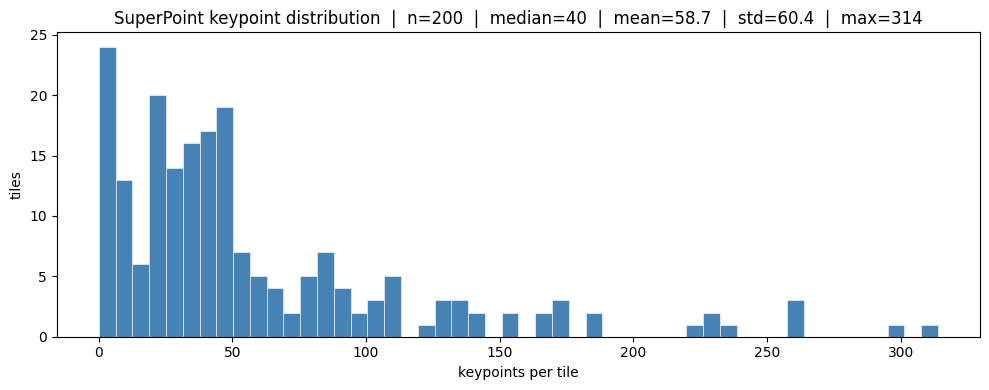

In [6]:
import matplotlib.pyplot as plt

with open(HE_KEYPOINT_ANNOTATION_PATH, "r", encoding="utf-8") as f:
    jobs = json.load(f)

counts = [j["fixed_keypoint_count"] for j in jobs]
mean = sum(counts) / len(counts)
std = (sum((c - mean) ** 2 for c in counts) / len(counts)) ** 0.5
median = sorted(counts)[len(counts) // 2]

print(f"n      : {len(counts)}")
print(f"min    : {min(counts)}")
print(f"max    : {max(counts)}")
print(f"median : {median}")
print(f"mean   : {mean:.1f}")
print(f"std    : {std:.1f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(counts, bins=50, color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_xlabel("keypoints per tile")
ax.set_ylabel("tiles")
ax.set_title(
    f"SuperPoint keypoint distribution  |  "
    f"n={len(counts)}  |  median={median}  |  "
    f"mean={mean:.1f}  |  std={std:.1f}  |  max={max(counts)}"
)
plt.tight_layout()
plt.show()

## Threshold Correction Loop

Re-runs SuperPoint on every non-converged tile with a per-tile adjusted `conf_thresh`, targeting `KEYPOINT_TARGET` keypoints. Loops until all tiles have converged or exhausted `MAX_CORRECTION_PASSES`. Saves on interrupt and resumes cleanly on re-run.

In [7]:
with open(HE_KEYPOINT_ANNOTATION_PATH, "r", encoding="utf-8") as f:
    annotated_jobs = json.load(f)

passes_run = 0
interrupted = False

try:
    while True:
        remaining = [
            j for j in annotated_jobs
            if not j.get("converged", False) and j.get("correction_passes", 0) < MAX_CORRECTION_PASSES
        ]
        if not remaining:
            break

        print(f"Pass {passes_run + 1}: {len(remaining)} tiles to correct")
        run_correction_pass(annotated_jobs, detector, log_every=LOG_EVERY)
        passes_run += 1

        converged_now = sum(1 for j in annotated_jobs if j.get("converged", False))
        print(f"  converged: {converged_now}/{len(annotated_jobs)}")

except KeyboardInterrupt:
    interrupted = True
    print(f"\nInterrupted after {passes_run} passes")
finally:
    save_json(annotated_jobs, HE_KEYPOINT_ANNOTATION_PATH)

converged = sum(1 for j in annotated_jobs if j.get("converged", False))
status = "interrupted" if interrupted else "complete"
print(f"status        : {status}")
print(f"passes run    : {passes_run}")
print(f"converged     : {converged}/{len(annotated_jobs)}")
print(f"not converged : {len(annotated_jobs) - converged} (kept, marked converged=false)")
print(f"saved to      : {HE_KEYPOINT_ANNOTATION_PATH}")

Pass 1: 105 tiles to correct


/Users/alexanderhallmann/Desktop/medical-image-registration/external/SuperPointPretrainedNetwork.py:281: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  desc = torch.nn.functional.grid_sample(coarse_desc, samp_pts)


  100/105
  converged: 121/200
Pass 2: 79 tiles to correct
  converged: 180/200
Pass 3: 20 tiles to correct
  converged: 193/200
Pass 4: 7 tiles to correct
  converged: 194/200
Pass 5: 6 tiles to correct
  converged: 194/200
Pass 6: 6 tiles to correct
  converged: 195/200
Pass 7: 5 tiles to correct
  converged: 195/200
Pass 8: 5 tiles to correct
  converged: 195/200
Pass 9: 5 tiles to correct
  converged: 195/200
Pass 10: 5 tiles to correct
  converged: 195/200
Pass 11: 5 tiles to correct
  converged: 195/200
Pass 12: 5 tiles to correct
  converged: 195/200
Pass 13: 5 tiles to correct
  converged: 195/200
Pass 14: 5 tiles to correct
  converged: 195/200
Pass 15: 5 tiles to correct
  converged: 195/200
Pass 16: 5 tiles to correct
  converged: 195/200
Pass 17: 5 tiles to correct
  converged: 195/200
Pass 18: 5 tiles to correct
  converged: 195/200
Pass 19: 5 tiles to correct
  converged: 195/200
Pass 20: 5 tiles to correct
  converged: 195/200
status        : complete
passes run    : 20
